In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [01:05<00:00, 2.62MB/s]


In [ ]:
# dataloaders - feeds the model in batches.
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [ ]:
import torch.nn as nn
import torch.optim as optim

class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):

        latent = self.encoder(x)
        reconstructed = self.decoder(latent)

        return reconstructed, latent

In [ ]:
model = SparseAutoencoder()

In [ ]:
# optional for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
# define loss function
criterion = nn.MSELoss()

In [ ]:
# define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# sparsity loss function
def sparse_loss(latent):
    return torch.mean(torch.abs(latent))

In [ ]:
# defining sparsity weight
beta = 1e-3

In [ ]:
num_epochs = 10
beta = 1e-3

In [ ]:
for epoch in range(num_epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1)   # flatten
        images = images.to(device)

        # Forward pass
        reconstructed, latent = model(images)

        # Reconstruction loss
        reconstruction_loss = criterion(reconstructed, images)

        # Sparsity penalty
        sparsity = sparse_loss(latent)

        # Total loss
        loss = reconstruction_loss + beta * sparsity

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/10], Loss: 0.0202
Epoch [2/10], Loss: 0.0179
Epoch [3/10], Loss: 0.0168
Epoch [4/10], Loss: 0.0160
Epoch [5/10], Loss: 0.0153
Epoch [6/10], Loss: 0.0149
Epoch [7/10], Loss: 0.0145
Epoch [8/10], Loss: 0.0141
Epoch [9/10], Loss: 0.0135
Epoch [10/10], Loss: 0.0134


Steps to Plot Latent Space

In [17]:
# Extract Latent Representations
latents = []
labels = []

with torch.no_grad():
    for images, targets in test_loader:

        images = images.view(images.size(0), -1).to(device)

        _, latent = model(images)

        latents.append(latent.cpu())
        labels.append(targets)

latents = torch.cat(latents)
labels = torch.cat(labels)

In [18]:
# apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latents.numpy())

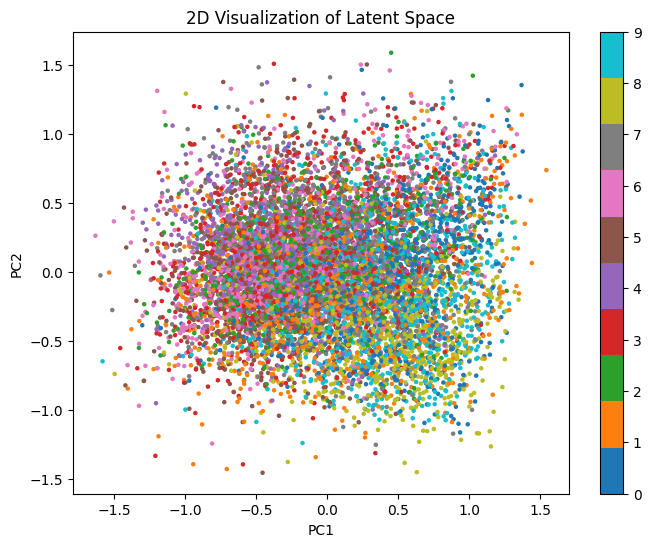

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    c=labels,
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.title("2D Visualization of Latent Space")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

Test

In [20]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.to(device)

In [21]:
images_flat = images.view(images.size(0), -1)

In [22]:
with torch.no_grad():
    reconstructed, _ = model(images_flat)

In [23]:
reconstructed = reconstructed.view(-1, 3, 32, 32)

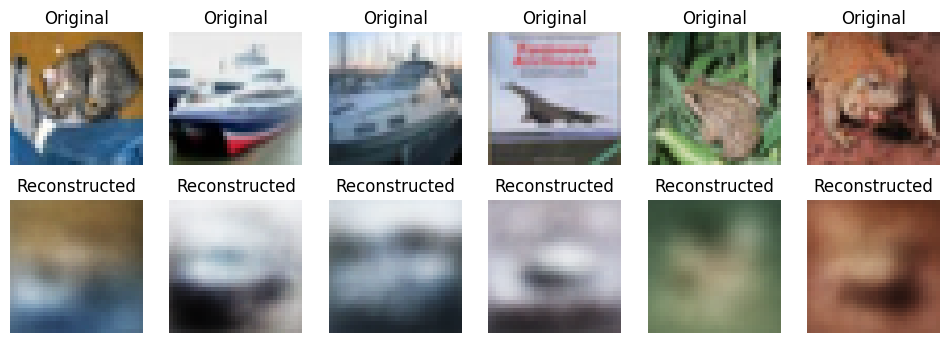

In [24]:
import matplotlib.pyplot as plt

n = 6

plt.figure(figsize=(12,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.title("Original")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(reconstructed[i].cpu().permute(1,2,0))
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()